In [2]:
# Section 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [3]:
# Section 2 — Paths
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed"
)

ML_FEATURES_PATH = (
    PROCESSED_DATA_DIR /
    "customer_features_ml.parquet"
)

RAW_FEATURES_PATH = (
    PROCESSED_DATA_DIR /
    "customer_features.parquet"
)

print("Project root:", PROJECT_ROOT)
print("ML features exist:", ML_FEATURES_PATH.exists())
print("Raw features exist:", RAW_FEATURES_PATH.exists())

Project root: C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ
ML features exist: True
Raw features exist: True


In [4]:
# Section 3 — Load the datasets
ml_df = pd.read_parquet(ML_FEATURES_PATH)
customer_features = pd.read_parquet(RAW_FEATURES_PATH)

print("ML dataset:", ml_df.shape)
print("Raw customer features:", customer_features.shape)

ML dataset: (5878, 11)
Raw customer features: (5878, 16)


In [5]:
# Section 4 — Define the ML matrix
feature_columns = [
    "recency_days",
    "log_frequency",
    "log_monetary",
    "log_average_order_value",
    "log_avg_items_per_order",
    "log_unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

In [6]:
X = ml_df[feature_columns].copy()

print("X shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

X shape: (5878, 10)
Missing values: 0


In [7]:
# Section 5 — Verify the feature ranges
X.describe().T

,count,mean,std,min,25%,50%,75%,max
recency_days,"5,878.000",0.000,1.000,-0.959,-0.840,-0.506,0.851,2.567
log_frequency,"5,878.000",0.000,1.000,-1.058,-1.058,-0.202,0.655,5.485
log_monetary,"5,878.000",0.000,1.000,-3.929,-0.706,-0.036,0.651,4.660
log_average_order_value,"5,878.000",0.000,1.000,-5.764,-0.594,0.025,0.562,7.776
log_avg_items_per_order,"5,878.000",-0.000,1.000,-4.645,-0.510,0.050,0.603,6.892
log_unique_products,"5,878.000",-0.000,1.000,-2.516,-0.627,0.057,0.726,3.351
purchase_span_days,"5,878.000",0.000,1.000,-1.056,-1.056,-0.202,0.921,1.795
return_order_share,"5,878.000",-0.000,1.000,-0.710,-0.710,-0.710,0.610,4.124
return_value_share,"5,878.000",0.000,1.000,-0.344,-0.344,-0.344,-0.106,10.818
has_return,"5,878.000",-0.000,1.000,-0.864,-0.864,-0.864,1.158,1.158


In [8]:
X.std()

recency_days              1.000
log_frequency             1.000
log_monetary              1.000
log_average_order_value   1.000
log_avg_items_per_order   1.000
log_unique_products       1.000
purchase_span_days        1.000
return_order_share        1.000
return_value_share        1.000
has_return                1.000
dtype: float64

In [9]:
# Section 6 — Baseline K-Means
k_values = range(2, 11)

results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    })

results_df = pd.DataFrame(results)

results_df

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,"40,637.095",0.294,"2,623.412",1.344
1,3,"33,625.993",0.302,"2,197.404",1.391
2,4,"28,787.129",0.252,"2,040.016",1.342
3,5,"25,606.252",0.260,"1,902.171",1.267
4,6,"23,132.243",0.242,"1,809.800",1.271
5,7,"21,649.494",0.215,"1,678.202",1.383
6,8,"20,375.650",0.206,"1,580.553",1.413
7,9,"19,150.615",0.211,"1,518.130",1.334
8,10,"18,196.704",0.209,"1,454.141",1.355


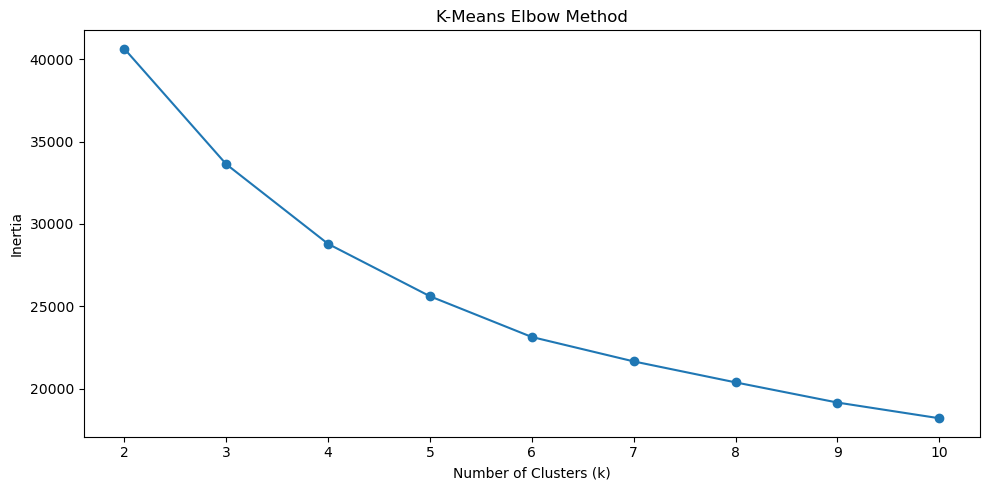

In [10]:
# Section 7 — Elbow Method
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["k"],
    results_df["inertia"],
    marker="o"
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

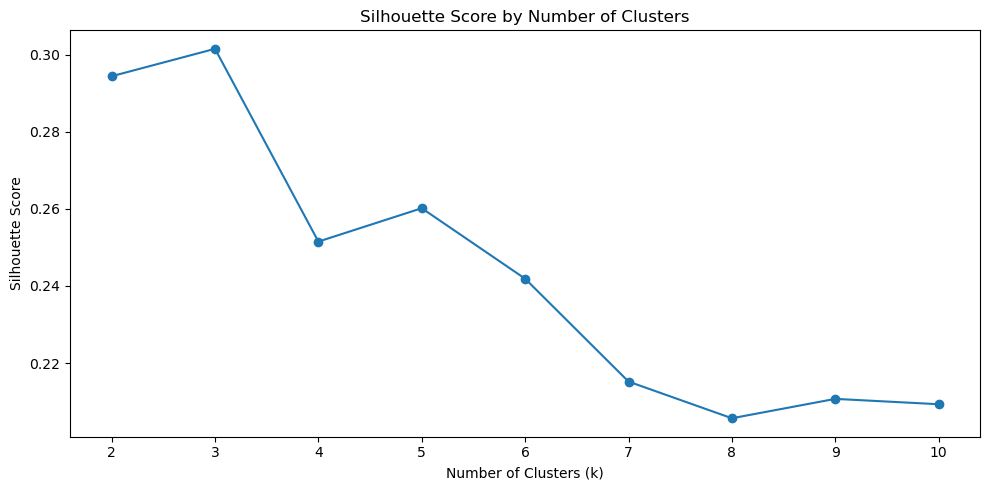

In [11]:
# Section 8 — Silhouette Score
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["k"],
    results_df["silhouette"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

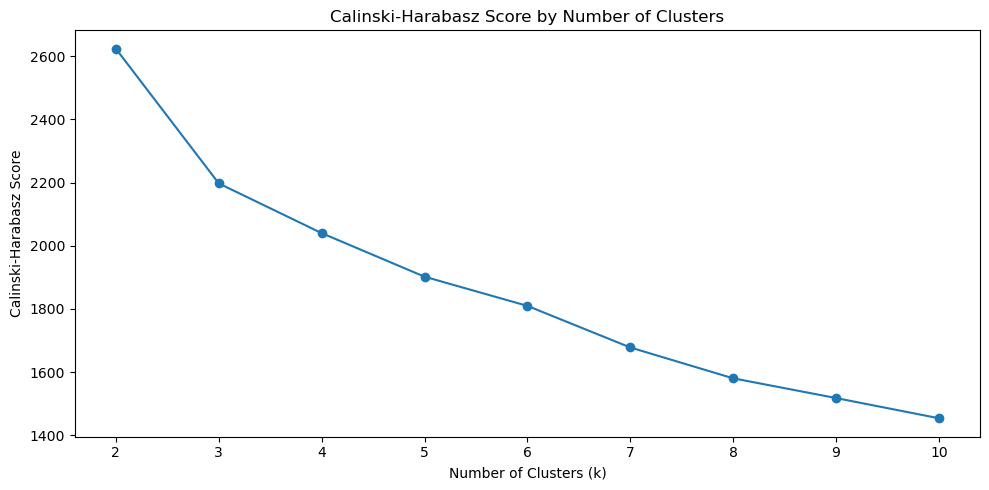

In [12]:
# Section 9 — Calinski-Harabasz
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["k"],
    results_df["calinski_harabasz"],
    marker="o"
)

plt.title("Calinski-Harabasz Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

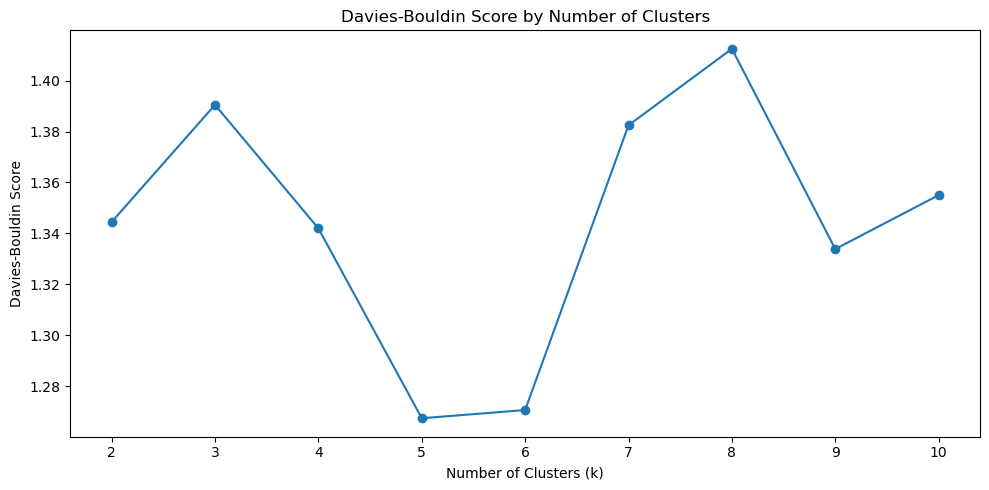

In [13]:
# Section 10 — Davies-Bouldin
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["k"],
    results_df["davies_bouldin"],
    marker="o"
)

plt.title("Davies-Bouldin Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [14]:
# Section 11 — Inspect candidate cluster sizes
def evaluate_k(k, X):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    return model, labels

In [16]:
# Section 11 — Candidate Cluster Analysis
candidate_ks = [3, 5, 6]

candidate_models = {}
candidate_labels = {}
candidate_profiles = {}

In [17]:
for k in candidate_ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    candidate_models[k] = model
    candidate_labels[k] = labels

    profile = pd.DataFrame({
        "cluster": labels
    }).value_counts().sort_index()

    candidate_profiles[k] = profile

In [18]:
for k in candidate_ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    candidate_models[k] = model
    candidate_labels[k] = labels

    profile = pd.DataFrame({
        "cluster": labels
    }).value_counts().sort_index()

    candidate_profiles[k] = profile

In [19]:
# Section 12 — Build cluster profiles
profile_features = [
    "recency_days",
    "frequency",
    "monetary",
    "average_order_value",
    "avg_items_per_order",
    "unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

In [20]:
candidate_profile_tables = {}

for k in candidate_ks:

    profile_df = customer_features[
        ["Customer ID"] + profile_features
    ].copy()

    profile_df["cluster"] = candidate_labels[k]

    profile = (
        profile_df
        .groupby("cluster")[profile_features]
        .agg("mean")
        .round(2)
    )

    candidate_profile_tables[k] = profile

    print(f"\n{'='*60}")
    print(f"K = {k} — RAW CLUSTER PROFILE")
    print(f"{'='*60}")

    display(profile)


K = 3 — RAW CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,270.450,3.130,"1,397.830",504.080,256.040,43.690,184.540,0.380,0.100,1.000
1,56.340,13.760,"7,090.690",470.960,353.810,168.460,539.930,0.150,0.020,0.720
2,282.420,2.020,522.890,279.090,167.190,33.210,112.290,0.000,0.000,0.000



K = 5 — RAW CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,379.480,1.460,248.160,183.380,103.340,17.190,41.640,0.000,0.000,0.000
1,238.440,3.480,"1,092.630",360.410,210.570,50.770,218.100,0.350,0.050,1.000
2,143.990,3.640,"1,255.150",414.900,308.500,70.070,268.960,0.000,0.000,0.000
3,46.410,17.440,"9,419.960",480.860,315.360,196.820,585.350,0.190,0.020,0.940
4,309.580,2.860,"4,563.590","1,603.110",699.800,27.600,136.280,0.440,0.410,1.000



K = 6 — RAW CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,310.670,1.580,691.480,456.230,360.070,35.420,48.290,0.000,0.000,0.000
1,84.730,5.420,"1,593.880",303.960,188.290,93.880,417.930,0.000,0.000,0.010
2,47.140,17.540,"9,664.640",493.870,323.370,195.640,582.830,0.200,0.030,0.980
3,240.230,3.460,"1,093.790",362.750,212.060,51.010,215.290,0.350,0.050,1.000
4,353.980,1.560,194.910,130.900,65.350,14.290,50.500,0.000,0.000,0.010
5,311.590,2.860,"4,601.430","1,616.420",705.740,27.830,135.650,0.440,0.410,1.000


In [21]:
for k in candidate_ks:

    profile_df = customer_features[
        ["Customer ID"] + profile_features
    ].copy()

    profile_df["cluster"] = candidate_labels[k]

    median_profile = (
        profile_df
        .groupby("cluster")[profile_features]
        .median()
        .round(2)
    )

    print(f"\n{'='*60}")
    print(f"K = {k} — MEDIAN CLUSTER PROFILE")
    print(f"{'='*60}")

    display(median_profile)


K = 3 — MEDIAN CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,250.490,3.000,790.790,291.860,149.170,34.000,140.160,0.330,0.040,1.000
1,28.820,9.000,"3,174.940",352.510,208.220,128.000,582.860,0.140,0.010,1.000
2,263.490,2.000,374.580,214.090,121.830,24.000,0.000,0.000,0.000,0.000



K = 5 — MEDIAN CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,401.010,1.000,207.800,157.600,82.000,13.000,0.000,0.000,0.000,0.000
1,198.960,3.000,929.800,295.140,156.900,40.000,193.070,0.330,0.030,1.000
2,72.120,3.000,898.870,315.880,190.200,51.000,257.100,0.000,0.000,0.000
3,23.930,12.000,"4,426.280",367.640,213.860,154.000,621.930,0.170,0.010,1.000
4,299.920,2.000,445.100,242.400,83.500,10.500,0.010,0.500,0.410,1.000



K = 6 — MEDIAN CLUSTER PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,365.480,1.000,461.530,336.770,202.000,27.000,0.000,0.000,0.000,0.000
1,45.910,4.000,"1,167.500",253.180,145.540,74.000,414.900,0.000,0.000,0.000
2,23.970,12.000,"4,459.980",373.120,217.170,153.000,619.080,0.180,0.010,1.000
3,201.920,3.000,931.500,297.010,157.330,41.000,191.110,0.330,0.030,1.000
4,385.880,1.000,157.490,125.580,59.500,10.000,0.000,0.000,0.000,0.000
5,301.960,2.000,445.150,247.440,87.000,11.000,0.010,0.500,0.410,1.000


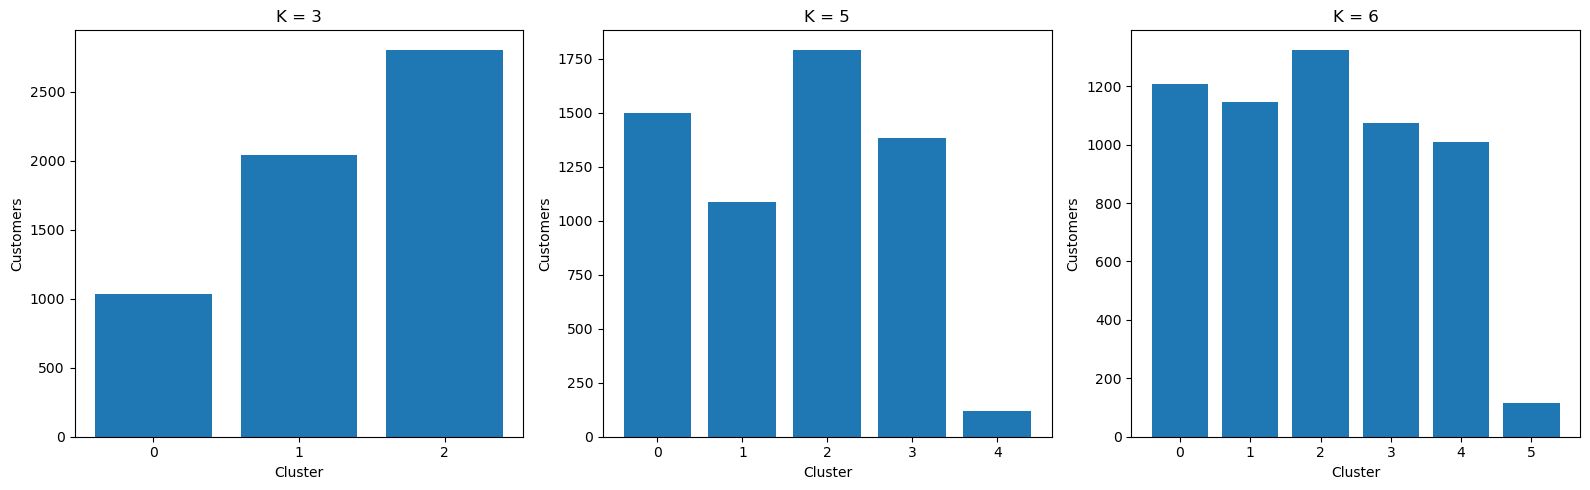

In [22]:
# Section 13 — Cluster size visualization
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

for ax, k in zip(axes, candidate_ks):

    sizes = (
        pd.Series(candidate_labels[k])
        .value_counts()
        .sort_index()
    )

    ax.bar(
        sizes.index.astype(str),
        sizes.values
    )

    ax.set_title(f"K = {k}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [23]:
# 1. Mean profiles
for k in candidate_ks:

    profile_df = customer_features[
        ["Customer ID"] + profile_features
    ].copy()

    profile_df["cluster"] = candidate_labels[k]

    profile = (
        profile_df
        .groupby("cluster")[profile_features]
        .mean()
        .round(2)
    )

    print(f"\n{'='*60}")
    print(f"K = {k} — MEAN PROFILE")
    print(f"{'='*60}")

    display(profile)


K = 3 — MEAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,270.450,3.130,"1,397.830",504.080,256.040,43.690,184.540,0.380,0.100,1.000
1,56.340,13.760,"7,090.690",470.960,353.810,168.460,539.930,0.150,0.020,0.720
2,282.420,2.020,522.890,279.090,167.190,33.210,112.290,0.000,0.000,0.000



K = 5 — MEAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,379.480,1.460,248.160,183.380,103.340,17.190,41.640,0.000,0.000,0.000
1,238.440,3.480,"1,092.630",360.410,210.570,50.770,218.100,0.350,0.050,1.000
2,143.990,3.640,"1,255.150",414.900,308.500,70.070,268.960,0.000,0.000,0.000
3,46.410,17.440,"9,419.960",480.860,315.360,196.820,585.350,0.190,0.020,0.940
4,309.580,2.860,"4,563.590","1,603.110",699.800,27.600,136.280,0.440,0.410,1.000



K = 6 — MEAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,310.670,1.580,691.480,456.230,360.070,35.420,48.290,0.000,0.000,0.000
1,84.730,5.420,"1,593.880",303.960,188.290,93.880,417.930,0.000,0.000,0.010
2,47.140,17.540,"9,664.640",493.870,323.370,195.640,582.830,0.200,0.030,0.980
3,240.230,3.460,"1,093.790",362.750,212.060,51.010,215.290,0.350,0.050,1.000
4,353.980,1.560,194.910,130.900,65.350,14.290,50.500,0.000,0.000,0.010
5,311.590,2.860,"4,601.430","1,616.420",705.740,27.830,135.650,0.440,0.410,1.000


In [24]:
# 2. Median profiles
for k in candidate_ks:

    profile_df = customer_features[
        ["Customer ID"] + profile_features
    ].copy()

    profile_df["cluster"] = candidate_labels[k]

    median_profile = (
        profile_df
        .groupby("cluster")[profile_features]
        .median()
        .round(2)
    )

    print(f"\n{'='*60}")
    print(f"K = {k} — MEDIAN PROFILE")
    print(f"{'='*60}")

    display(median_profile)


K = 3 — MEDIAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,250.490,3.000,790.790,291.860,149.170,34.000,140.160,0.330,0.040,1.000
1,28.820,9.000,"3,174.940",352.510,208.220,128.000,582.860,0.140,0.010,1.000
2,263.490,2.000,374.580,214.090,121.830,24.000,0.000,0.000,0.000,0.000



K = 5 — MEDIAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,401.010,1.000,207.800,157.600,82.000,13.000,0.000,0.000,0.000,0.000
1,198.960,3.000,929.800,295.140,156.900,40.000,193.070,0.330,0.030,1.000
2,72.120,3.000,898.870,315.880,190.200,51.000,257.100,0.000,0.000,0.000
3,23.930,12.000,"4,426.280",367.640,213.860,154.000,621.930,0.170,0.010,1.000
4,299.920,2.000,445.100,242.400,83.500,10.500,0.010,0.500,0.410,1.000



K = 6 — MEDIAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,365.480,1.000,461.530,336.770,202.000,27.000,0.000,0.000,0.000,0.000
1,45.910,4.000,"1,167.500",253.180,145.540,74.000,414.900,0.000,0.000,0.000
2,23.970,12.000,"4,459.980",373.120,217.170,153.000,619.080,0.180,0.010,1.000
3,201.920,3.000,931.500,297.010,157.330,41.000,191.110,0.330,0.030,1.000
4,385.880,1.000,157.490,125.580,59.500,10.000,0.000,0.000,0.000,0.000
5,301.960,2.000,445.150,247.440,87.000,11.000,0.010,0.500,0.410,1.000


In [26]:
# Section 14 — K-Means Stability

stability_results = []

for seed in [0, 21, 42, 63, 84]:

    model = KMeans(
        n_clusters=5,
        random_state=seed,
        n_init=20
    )

    labels = model.fit_predict(X)

    stability_results.append({
        "random_state": seed,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,random_state,inertia,silhouette,calinski_harabasz,davies_bouldin
0,0,"25,606.252",0.260,"1,902.171",1.267
1,21,"25,606.227",0.260,"1,902.171",1.267
2,42,"25,606.252",0.260,"1,902.171",1.267
3,63,"25,606.246",0.260,"1,902.168",1.267
4,84,"25,606.217",0.260,"1,902.171",1.267


In [27]:
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X)

In [28]:
# Section 15 — Final K-Means Model
# Section 15 — Final K-Means Model

FINAL_K = 5

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X)

print("Final K-Means fitted successfully.")
print("Number of clusters:", FINAL_K)

Final K-Means fitted successfully.
Number of clusters: 5


In [29]:
final_silhouette = silhouette_score(X, final_labels)
final_calinski = calinski_harabasz_score(X, final_labels)
final_davies = davies_bouldin_score(X, final_labels)

print(f"Silhouette Score:       {final_silhouette:.3f}")
print(f"Calinski-Harabasz:      {final_calinski:,.2f}")
print(f"Davies-Bouldin:         {final_davies:.3f}")

Silhouette Score:       0.260
Calinski-Harabasz:      1,902.17
Davies-Bouldin:         1.267


In [30]:
# Section 16 — Attach cluster labels
clustered_customers = customer_features.copy()

clustered_customers["cluster"] = final_labels

In [31]:
clustered_customers[
    ["Customer ID", "cluster"]
].head(10)

,Customer ID,cluster
0,12346,4
1,12347,2
2,12348,2
3,12349,3
4,12350,0
5,12351,0
6,12352,1
7,12353,2
8,12354,2
9,12355,2


In [32]:
# Section 17 — Cluster distribution
cluster_distribution = (
    clustered_customers["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

cluster_distribution["percentage"] = (
    cluster_distribution["customers"] /
    len(clustered_customers) *
    100
)

cluster_distribution

,customers,percentage
cluster,,
0,1498,25.485
1,1088,18.510
2,1791,30.470
3,1383,23.528
4,118,2.007


In [33]:
# Section 18 — Final raw cluster profile
profile_features = [
    "recency_days",
    "frequency",
    "monetary",
    "average_order_value",
    "avg_items_per_order",
    "unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

final_profile_mean = (
    clustered_customers
    .groupby("cluster")[profile_features]
    .mean()
    .round(2)
)

final_profile_median = (
    clustered_customers
    .groupby("cluster")[profile_features]
    .median()
    .round(2)
)

In [34]:
print("MEAN PROFILE")
display(final_profile_mean)

print("\nMEDIAN PROFILE")
display(final_profile_median)

MEAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,379.480,1.460,248.160,183.380,103.340,17.190,41.640,0.000,0.000,0.000
1,238.440,3.480,"1,092.630",360.410,210.570,50.770,218.100,0.350,0.050,1.000
2,143.990,3.640,"1,255.150",414.900,308.500,70.070,268.960,0.000,0.000,0.000
3,46.410,17.440,"9,419.960",480.860,315.360,196.820,585.350,0.190,0.020,0.940
4,309.580,2.860,"4,563.590","1,603.110",699.800,27.600,136.280,0.440,0.410,1.000



MEDIAN PROFILE


,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days,return_order_share,return_value_share,has_return
cluster,,,,,,,,,,
0,401.010,1.000,207.800,157.600,82.000,13.000,0.000,0.000,0.000,0.000
1,198.960,3.000,929.800,295.140,156.900,40.000,193.070,0.330,0.030,1.000
2,72.120,3.000,898.870,315.880,190.200,51.000,257.100,0.000,0.000,0.000
3,23.930,12.000,"4,426.280",367.640,213.860,154.000,621.930,0.170,0.010,1.000
4,299.920,2.000,445.100,242.400,83.500,10.500,0.010,0.500,0.410,1.000


In [37]:
# Section 19 — Cluster Behavioral Index
index_features = [
    "recency_days",
    "frequency",
    "monetary",
    "average_order_value",
    "avg_items_per_order",
    "unique_products",
    "purchase_span_days"
]

overall_median = (
    clustered_customers[index_features]
    .median()
)

cluster_median = (
    clustered_customers
    .groupby("cluster")[index_features]
    .median()
)

cluster_index = (
    cluster_median /
    overall_median
).round(2)

cluster_index

,recency_days,frequency,monetary,average_order_value,avg_items_per_order,unique_products,purchase_span_days
cluster,,,,,,,
0,4.180,0.330,0.240,0.560,0.530,0.290,0.000
1,2.070,1.000,1.070,1.060,1.020,0.890,0.870
2,0.750,1.000,1.040,1.130,1.240,1.130,1.160
3,0.250,4.000,5.100,1.320,1.390,3.420,2.810
4,3.120,0.670,0.510,0.870,0.540,0.230,0.000


In [38]:
# 4. Also calculate revenue contribution
cluster_revenue = (
    clustered_customers
    .groupby("cluster")
    .agg(
        customers=("Customer ID", "nunique"),
        revenue=("monetary", "sum")
    )
)

cluster_revenue["customer_share"] = (
    cluster_revenue["customers"] /
    cluster_revenue["customers"].sum() *
    100
)

cluster_revenue["revenue_share"] = (
    cluster_revenue["revenue"] /
    cluster_revenue["revenue"].sum() *
    100
)

cluster_revenue["revenue_per_customer"] = (
    cluster_revenue["revenue"] /
    cluster_revenue["customers"]
)

cluster_revenue.round(2)

,customers,revenue,customer_share,revenue_share,revenue_per_customer
cluster,,,,,
0,1498,"371,751.030",25.480,2.140,248.160
1,1088,"1,188,778.970",18.510,6.840,"1,092.630"
2,1791,"2,247,965.340",30.470,12.940,"1,255.150"
3,1383,"13,027,805.050",23.530,74.980,"9,419.960"
4,118,"538,503.870",2.010,3.100,"4,563.590"


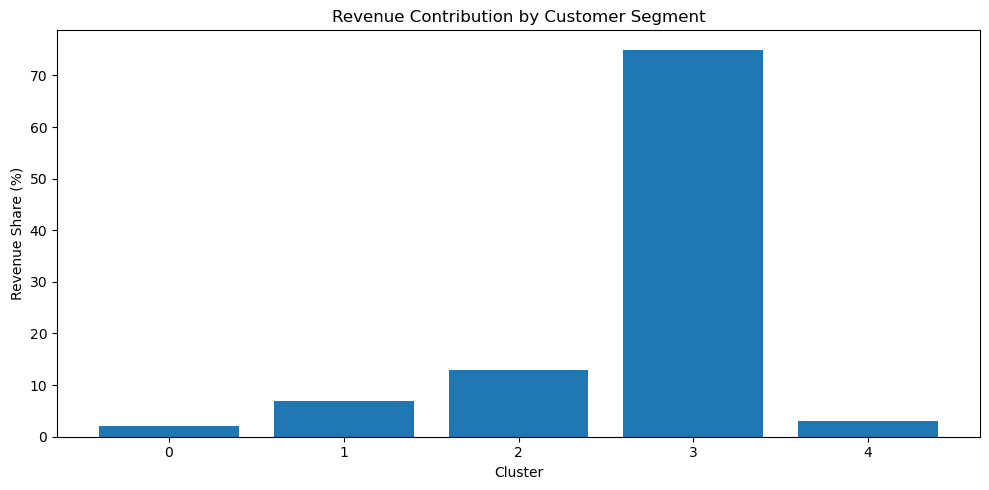

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(
    cluster_revenue.index.astype(str),
    cluster_revenue["revenue_share"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Revenue Share (%)")

plt.tight_layout()
plt.show()

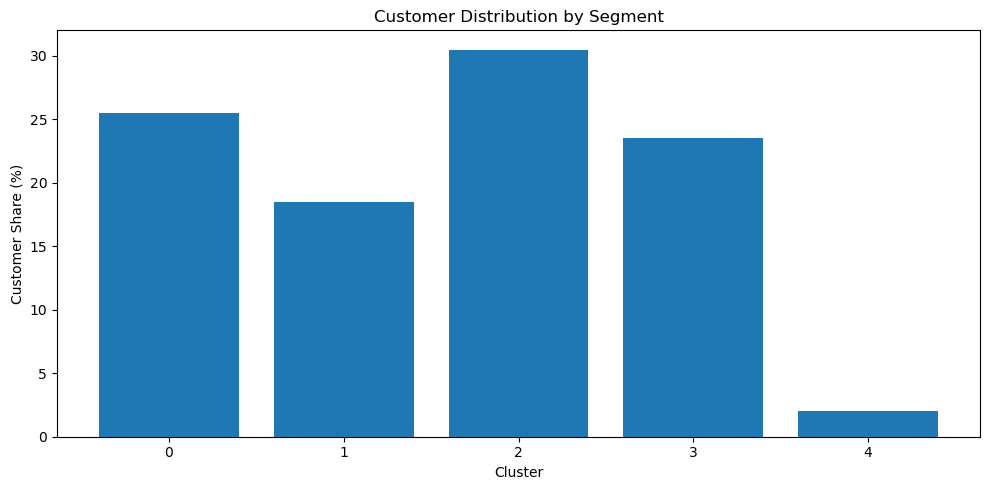

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    cluster_revenue.index.astype(str),
    cluster_revenue["customer_share"]
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Cluster")
plt.ylabel("Customer Share (%)")

plt.tight_layout()
plt.show()

In [41]:
# Section 20 — Save K-Means Customer Segments

KMEANS_OUTPUT_PATH = (
    PROCESSED_DATA_DIR /
    "customer_segments_kmeans.parquet"
)

clustered_customers.to_parquet(
    KMEANS_OUTPUT_PATH,
    index=False
)

print("Saved:", KMEANS_OUTPUT_PATH)

Saved: C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ\data\processed\customer_segments_kmeans.parquet


In [42]:
check_df = pd.read_parquet(KMEANS_OUTPUT_PATH)

print("Shape:", check_df.shape)
print("Clusters:", sorted(check_df["cluster"].unique()))
print(check_df["cluster"].value_counts().sort_index())

Shape: (5878, 17)
Clusters: [0, 1, 2, 3, 4]
cluster
0    1498
1    1088
2    1791
3    1383
4     118
Name: count, dtype: int64
